In [1]:
### pip install pystan
### conda install -c conda-forge fbprophet
!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('/content/MBG.DE.csv')

In [3]:
df.shape


(1105, 7)

In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-01-02,41.092484,41.845215,40.971882,41.566578,33.846729,2973654
1,2020-01-03,41.296261,41.362801,40.302322,40.813847,33.233799,4014262
2,2020-01-06,40.202515,40.593433,39.703465,40.593433,33.054317,3441396
3,2020-01-07,40.797215,41.208927,40.680767,40.917816,33.318455,2816618
4,2020-01-08,40.589275,41.167339,40.489468,41.146545,33.504704,2659070


In [5]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1100,2024-04-24,74.150002,74.440002,73.769997,74.019997,74.019997,2223226
1101,2024-04-25,74.360001,74.360001,72.360001,73.220001,73.220001,2689932
1102,2024-04-26,73.639999,74.790001,73.260002,74.360001,74.360001,2632815
1103,2024-04-29,75.000000,75.279999,74.519997,74.790001,74.790001,2456200
1104,2024-04-30,73.209999,73.790001,70.410004,70.940002,70.940002,8393648


<Axes: >

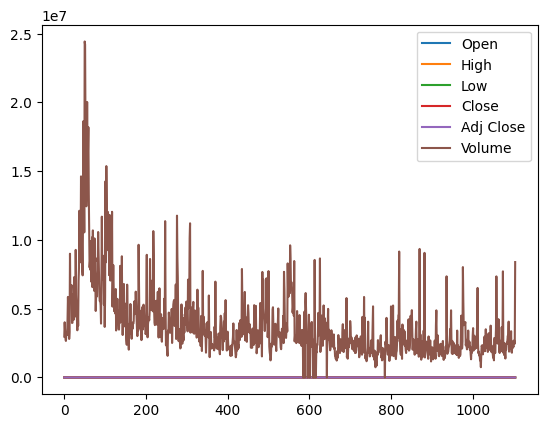

In [6]:
df.plot()

In [9]:
df = df[['Date', 'Close']]
df.columns = ['ds','y']
df.head()

KeyError: "None of [Index(['Date', 'Close'], dtype='object')] are in the [columns]"

In [10]:
df.drop(144,axis=0,inplace=True)

/tmp/ipykernel_1356/1840911871.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(144,axis=0,inplace=True)


In [11]:
df.tail()

,ds,y
1100,2024-04-24,74.019997
1101,2024-04-25,73.220001
1102,2024-04-26,74.360001
1103,2024-04-29,74.790001
1104,2024-04-30,70.940002


In [12]:
df['ds'] = pd.to_datetime(df['ds'])

/tmp/ipykernel_1356/3173280147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ds'] = pd.to_datetime(df['ds'])


In [13]:
df.head()

,ds,y
0,2020-01-02,41.566578
1,2020-01-03,40.813847
2,2020-01-06,40.593433
3,2020-01-07,40.917816
4,2020-01-08,41.146545


In [14]:
df.tail()

,ds,y
1100,2024-04-24,74.019997
1101,2024-04-25,73.220001
1102,2024-04-26,74.360001
1103,2024-04-29,74.790001
1104,2024-04-30,70.940002


In [15]:
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [16]:
# Initialize the Model
model=Prophet()

In [17]:
df.columns

Index(['ds', 'y'], dtype='object')

In [18]:
df.dropna(axis=0,inplace=True)
df.head()

/tmp/ipykernel_1356/2384546804.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(axis=0,inplace=True)


,ds,y
0,2020-01-02,41.566578
1,2020-01-03,40.813847
2,2020-01-06,40.593433
3,2020-01-07,40.917816
4,2020-01-08,41.146545


In [19]:
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [20]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [21]:
df.tail()

,ds,y
1100,2024-04-24,74.019997
1101,2024-04-25,73.220001
1102,2024-04-26,74.360001
1103,2024-04-29,74.790001
1104,2024-04-30,70.940002


In [22]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [23]:
future_dates.tail()

,ds
1464,2025-04-26
1465,2025-04-27
1466,2025-04-28
1467,2025-04-29
1468,2025-04-30


In [24]:
prediction=model.predict(future_dates)

In [25]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-02,38.736771,33.368530,41.387450,38.736771,38.736771,-1.316979,-1.316979,-1.316979,-0.468982,-0.468982,-0.468982,-0.847997,-0.847997,-0.847997,0.0,0.0,0.0,37.419791
1,2020-01-03,38.571019,33.397590,41.320740,38.571019,38.571019,-1.145913,-1.145913,-1.145913,-0.448652,-0.448652,-0.448652,-0.697261,-0.697261,-0.697261,0.0,0.0,0.0,37.425106
2,2020-01-06,38.073765,33.024427,41.149338,38.073765,38.073765,-0.787766,-0.787766,-0.787766,-0.445591,-0.445591,-0.445591,-0.342175,-0.342175,-0.342175,0.0,0.0,0.0,37.285999
3,2020-01-07,37.908014,33.138223,41.132614,37.908014,37.908014,-0.631906,-0.631906,-0.631906,-0.369681,-0.369681,-0.369681,-0.262225,-0.262225,-0.262225,0.0,0.0,0.0,37.276108
4,2020-01-08,37.742263,33.575938,41.208243,37.742263,37.742263,-0.556895,-0.556895,-0.556895,-0.353664,-0.353664,-0.353664,-0.203231,-0.203231,-0.203231,0.0,0.0,0.0,37.185367


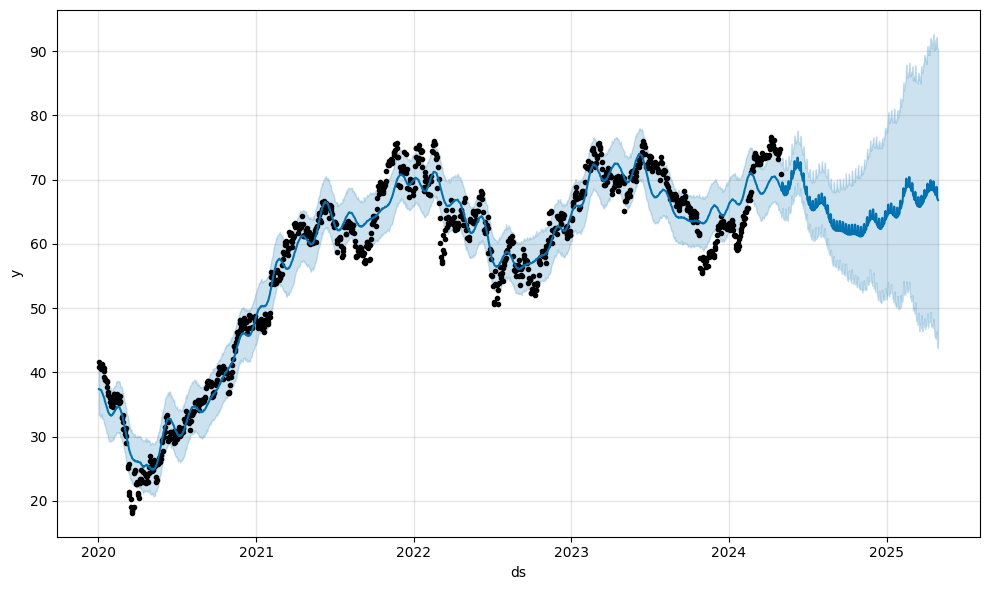

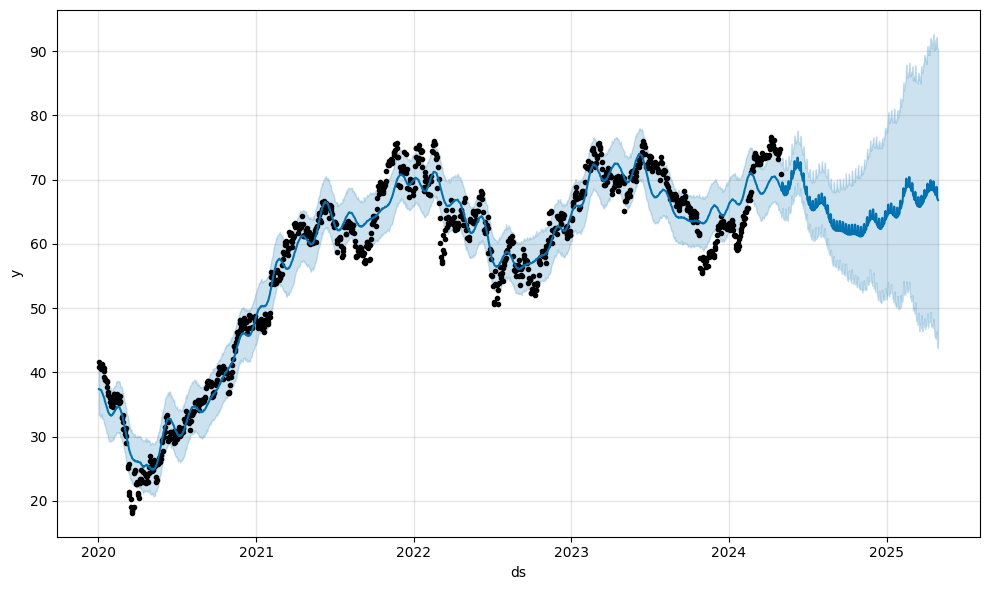

In [26]:
### plot the predicted projection
model.plot(prediction)

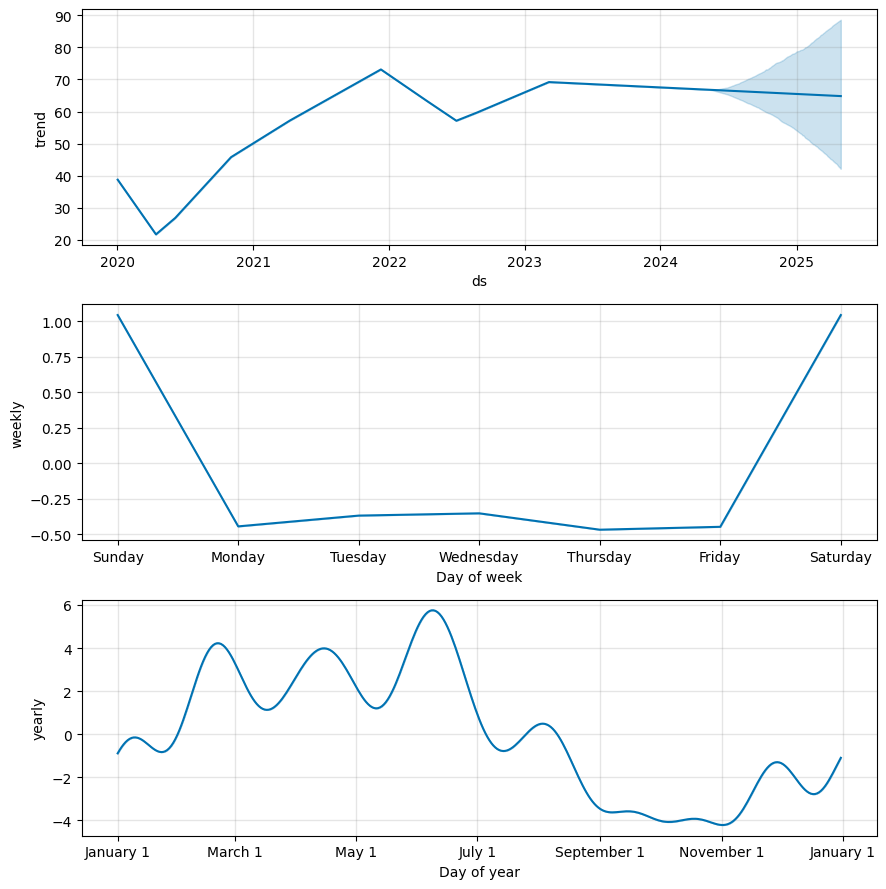

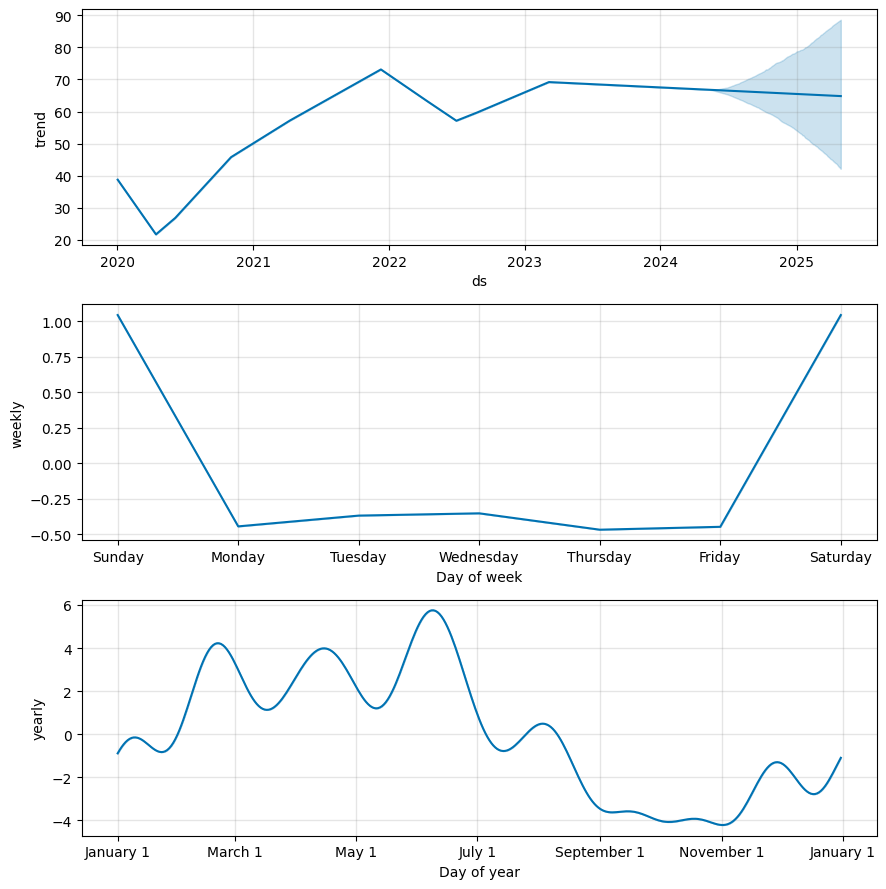

In [27]:
#### Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [28]:
#Time Series Analysis

1960-1962
#Cross Validation
1960-61 #Train dataset
1961-62 #Test dataset
1962-63 #Validation

1899

In [29]:
df.head()

,ds,y
0,2020-01-02,41.566578
1,2020-01-03,40.813847
2,2020-01-06,40.593433
3,2020-01-07,40.917816
4,2020-01-08,41.146545


In [30]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

INFO:prophet:Making 3 forecasts with cutoffs between 2022-05-06 00:00:00 and 2023-05-01 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2022-05-09,62.706868,60.152452,65.332386,60.560001,2022-05-06
1,2022-05-10,62.811433,60.113155,65.411599,61.130001,2022-05-06
2,2022-05-11,62.920450,60.170570,65.587947,63.860001,2022-05-06
3,2022-05-12,62.766783,60.140183,65.255352,63.509998,2022-05-06
4,2022-05-13,62.733398,60.074879,65.206301,63.509998,2022-05-06


In [31]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,15.391080,3.923147,3.264774,0.049207,0.043336,0.049016,0.526316
1,37 days,16.504507,4.062574,3.392439,0.051058,0.044729,0.050922,0.500000
2,38 days,16.808775,4.099851,3.441926,0.051729,0.045463,0.051556,0.480263
3,39 days,16.993571,4.122326,3.475888,0.052159,0.046440,0.051971,0.467105
4,40 days,17.714752,4.208890,3.560999,0.053495,0.051255,0.053405,0.447368


https://docs.google.com/document/d/1kflJtIrV23DaGH2bF7fLJyTYq-uqsu2D7SFrRpdQ3bk/edit?usp=sharing

In [32]:
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,15.391080,3.923147,3.264774,0.049207,0.043336,0.049016,0.526316
1,37 days,16.504507,4.062574,3.392439,0.051058,0.044729,0.050922,0.500000
2,38 days,16.808775,4.099851,3.441926,0.051729,0.045463,0.051556,0.480263
3,39 days,16.993571,4.122326,3.475888,0.052159,0.046440,0.051971,0.467105
4,40 days,17.714752,4.208890,3.560999,0.053495,0.051255,0.053405,0.447368


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


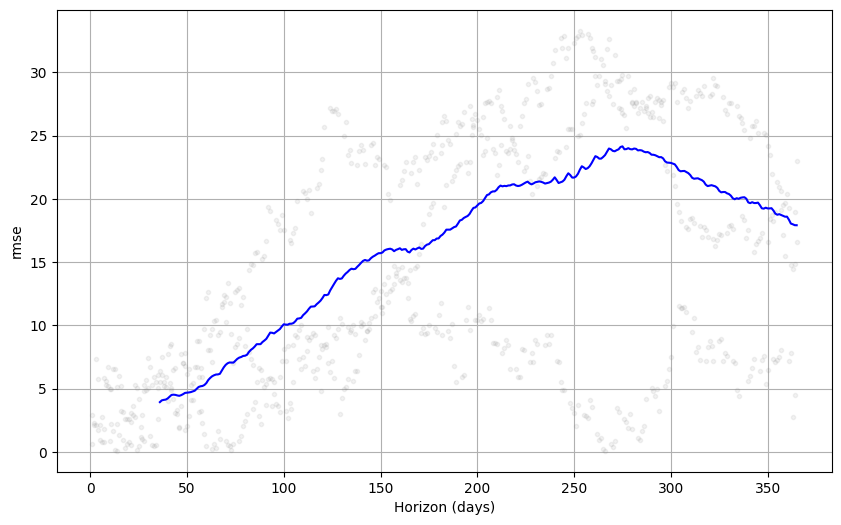

In [33]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

FINAL OUTCOME OF THE NOTEBOOK

This notebook successfully:

✅ Loads Mercedes-Benz Group Stock Price History & trading data

✅ Cleans and prepares dataset

✅ Trains Prophet forecasting model

✅ Predicts future CONSUMPTION counts for 365 days

✅ Visualizes trend and seasonality

✅ Evaluates model accuracy using cross-validation and RMSE